In [1]:
# 1

import sys

import numpy
import pandas
import sklearn

print(sys.version.split()[0], numpy.__version__, pandas.__version__, sklearn.__version__)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 2305

data = pd.read_csv("data/heart_disease.csv")
feature_names = [c for c in data.columns if c != "disease"]
X, y = data[feature_names].to_numpy(), data["disease"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
print(data.shape, round(y.mean(), 3), X_train.shape, X_test.shape)

toy = pd.DataFrame({
    "age_55_plus": [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0],
    "exercise_angina": [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "male": [1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
    "high_bp": [1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
    "disease": [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
})

3.13.0 2.5.3 3.0.5 1.9.1
(297, 14) 0.461 (207, 13) (90, 13)


In [ ]:
import math

import pandas as pd

TARGET = "disease"
FEATURES = ["age_55_plus", "exercise_angina", "male", "high_bp"]
WIDTH = 64


def title(text):
    print("\n" + "=" * WIDTH)
    print(text)
    print("=" * WIDTH)


def counts(data):
    """Return (number with disease, number healthy) in a table."""
    pos = int((data[TARGET] == 1).sum())
    return pos, len(data) - pos


def entropy_from_counts(pos, neg):
    """H = -sum(p * log2 p) over the non-empty classes (0 * log2 0 = 0)."""
    n = pos + neg
    return -sum((c / n) * math.log2(c / n) for c in (pos, neg) if c > 0) + 0.0   # "+ 0.0" avoids printing -0.0


def entropy(data):
    """Entropy in bits of the 'disease' column."""
    return entropy_from_counts(*counts(data))


def entropy_working(pos, neg):
    """Text of the entropy formula with the numbers substituted in."""
    n = pos + neg
    terms = [(c, (c / n) * math.log2(c / n)) for c in (pos, neg) if c > 0]
    if len(terms) == 1:
        return "pure node, so H = 0"
    symbolic = " + ".join(f"{c}/{n}*log2({c}/{n})" for c, _ in terms)
    numeric = " + ".join(f"({t:.4f})" for _, t in terms)
    return f"H = -({symbolic}) = -({numeric}) = {entropy_from_counts(pos, neg):.4f}"


def split_report(data, feature):
    """Print the full working for splitting `data` on `feature` and return the information gain."""
    n = len(data)
    parent_h = entropy(data)
    weighted, weighted_text = 0.0, []

    print(f"\nFeature: {feature}")
    for value in sorted(data[feature].unique()):
        child = data[data[feature] == value]
        pos, neg = counts(child)
        h = entropy_from_counts(pos, neg)
        weighted += (len(child) / n) * h
        weighted_text.append(f"{len(child)}/{n}*{h:.4f}")
        print(f"  {feature} = {value}: {len(child)} patients ({pos} disease, {neg} healthy)")
        print(f"      {entropy_working(pos, neg)}")

    gain = parent_h - weighted
    print(f"  Weighted entropy = {' + '.join(weighted_text)} = {weighted:.4f}")
    print(f"  Gain = {parent_h:.4f} - {weighted:.4f} = {gain:.4f}")
    return gain


def gain_table(gains):
    """Gains sorted from best to worst, with the winner marked."""
    table = pd.Series(gains, name="information gain").sort_values(ascending=False).round(4).to_frame()
    table["chosen"] = ["<-- best" if i == 0 else "" for i in range(len(table))]
    return table


def disease_rates(data, feature):
    """Share of patients with disease for each value of the feature, as 'k/n'."""
    return {int(v): f"{counts(g)[0]}/{len(g)}" for v, g in data.groupby(feature)}


title("1. PARENT ENTROPY")
pos, neg = counts(toy)
print(f"Patients: {len(toy)}  (disease = 1: {pos}, disease = 0: {neg})")
print("Formula: H(S) = -(p_yes*log2(p_yes) + p_no*log2(p_no))")
print(entropy_working(pos, neg))
parent_entropy = entropy(toy)

title("2. INFORMATION GAIN AT THE ROOT")
root_gains = {feature: split_report(toy, feature) for feature in FEATURES}

print("\nRoot gains:")
display(gain_table(root_gains))

root_feature = max(root_gains, key=root_gains.get)
print(f"ROOT FEATURE = {root_feature}")

title("3. ONE LEVEL DOWN")
print(f"Branches of the root '{root_feature}':")
impure_values = []
for value in sorted(toy[root_feature].unique()):
    child = toy[toy[root_feature] == value]
    pos, neg = counts(child)
    h = entropy(child)
    status = "impure" if h > 1e-12 else "pure -> leaf"
    print(f"  {root_feature} = {value}: {len(child)} patients ({pos} disease, {neg} healthy), H = {h:.4f}  [{status}]")
    if h > 1e-12:
        impure_values.append(value)

assert len(impure_values) == 1, "expected exactly one impure branch"
branch_value = impure_values[0]
branch = toy[toy[root_feature] == branch_value]

print(f"\nImpure branch: {root_feature} = {branch_value}")
display(branch)
print("Branch entropy:", entropy_working(*counts(branch)))

branch_features = [f for f in FEATURES if f != root_feature]
branch_gains = {feature: split_report(branch, feature) for feature in branch_features}

print("\nGains inside the branch:")
display(gain_table(branch_gains))

second_feature = max(branch_gains, key=branch_gains.get)
print(f"SECOND-LEVEL FEATURE = {second_feature}")

title("COMPARISON")
f = second_feature
print(f"Gain of '{f}' at the root         : {root_gains[f]:.4f}")
print(f"Gain of '{f}' inside the branch   : {branch_gains[f]:.4f}")
print()
n_pos, n_all = counts(toy)[0], len(toy)
print(f"Disease rate by '{f}' on all patients : {disease_rates(toy, f)}   (parent: {n_pos}/{n_all})")
print(f"Disease rate by '{f}' inside the branch: {disease_rates(branch, f)}")
print()
print("Explanation:")
if root_gains[f] < 1e-9:
    print(
        f"On all 12 patients every value of '{f}' leaves the same share of disease as the parent, "
        f"so the split does not purify anything and its gain at the root is {root_gains[f]:.4f}."
    )
else:
    print(f"At the root '{f}' has a gain of only {root_gains[f]:.4f}, much smaller than the root feature's.")
print(
    f"Gain is measured inside the current node: after '{root_feature}' has split the patients, "
    f"'{f}' separates the classes in the '{root_feature} = {branch_value}' branch "
    f"(gain {branch_gains[f]:.4f}), because its effect depends on '{root_feature}'."
)


1. PARENT ENTROPY
Patients: 12  (disease = 1: 6, disease = 0: 6)
Formula: H(S) = -(p_yes*log2(p_yes) + p_no*log2(p_no))
H = -(6/12*log2(6/12) + 6/12*log2(6/12)) = -((-0.5000) + (-0.5000)) = 1.0000

2. INFORMATION GAIN AT THE ROOT

Feature: age_55_plus
  age_55_plus = 0: 6 patients (1 disease, 5 healthy)
      H = -(1/6*log2(1/6) + 5/6*log2(5/6)) = -((-0.4308) + (-0.2192)) = 0.6500
  age_55_plus = 1: 6 patients (5 disease, 1 healthy)
      H = -(5/6*log2(5/6) + 1/6*log2(1/6)) = -((-0.2192) + (-0.4308)) = 0.6500
  Weighted entropy = 6/12*0.6500 + 6/12*0.6500 = 0.6500
  Gain = 1.0000 - 0.6500 = 0.3500

Feature: exercise_angina
  exercise_angina = 0: 8 patients (2 disease, 6 healthy)
      H = -(2/8*log2(2/8) + 6/8*log2(6/8)) = -((-0.5000) + (-0.3113)) = 0.8113
  exercise_angina = 1: 4 patients (4 disease, 0 healthy)
      pure node, so H = 0
  Weighted entropy = 8/12*0.8113 + 4/12*0.0000 = 0.5409
  Gain = 1.0000 - 0.5409 = 0.4591

Feature: male
  male = 0: 6 patients (3 disease, 3 health

,information gain,chosen
exercise_angina,0.4591,<-- best
age_55_plus,0.3500,
high_bp,0.0817,
male,0.0000,


ROOT FEATURE = exercise_angina

3. ONE LEVEL DOWN
Branches of the root 'exercise_angina':
  exercise_angina = 0: 8 patients (2 disease, 6 healthy), H = 0.8113  [impure]
  exercise_angina = 1: 4 patients (4 disease, 0 healthy), H = 0.0000  [pure -> leaf]

Impure branch: exercise_angina = 0


,age_55_plus,exercise_angina,male,high_bp,disease
4,1,0,0,1,1
5,0,0,0,0,1
6,1,0,1,0,0
7,0,0,1,0,0
8,0,0,1,0,0
9,0,0,0,1,0
10,0,0,0,1,0
11,0,0,0,0,0


Branch entropy: H = -(2/8*log2(2/8) + 6/8*log2(6/8)) = -((-0.5000) + (-0.3113)) = 0.8113

Feature: age_55_plus
  age_55_plus = 0: 6 patients (1 disease, 5 healthy)
      H = -(1/6*log2(1/6) + 5/6*log2(5/6)) = -((-0.4308) + (-0.2192)) = 0.6500
  age_55_plus = 1: 2 patients (1 disease, 1 healthy)
      H = -(1/2*log2(1/2) + 1/2*log2(1/2)) = -((-0.5000) + (-0.5000)) = 1.0000
  Weighted entropy = 6/8*0.6500 + 2/8*1.0000 = 0.7375
  Gain = 0.8113 - 0.7375 = 0.0738

Feature: male
  male = 0: 5 patients (2 disease, 3 healthy)
      H = -(2/5*log2(2/5) + 3/5*log2(3/5)) = -((-0.5288) + (-0.4422)) = 0.9710
  male = 1: 3 patients (0 disease, 3 healthy)
      pure node, so H = 0
  Weighted entropy = 5/8*0.9710 + 3/8*0.0000 = 0.6068
  Gain = 0.8113 - 0.6068 = 0.2044

Feature: high_bp
  high_bp = 0: 5 patients (1 disease, 4 healthy)
      H = -(1/5*log2(1/5) + 4/5*log2(4/5)) = -((-0.4644) + (-0.2575)) = 0.7219
  high_bp = 1: 3 patients (1 disease, 2 healthy)
      H = -(1/3*log2(1/3) + 2/3*log2(2/3))

,information gain,chosen
male,0.2044,<-- best
age_55_plus,0.0738,
high_bp,0.0157,


SECOND-LEVEL FEATURE = male

COMPARISON
Gain of 'male' at the root         : 0.0000
Gain of 'male' inside the branch   : 0.2044

Disease rate by 'male' on all patients : {0: '3/6', 1: '3/6'}   (parent: 6/12)
Disease rate by 'male' inside the branch: {0: '2/5', 1: '0/3'}

Explanation:
On all 12 patients every value of 'male' leaves the same share of disease as the parent, so the split does not purify anything and its gain at the root is 0.0000.
Gain is measured inside the current node: after 'exercise_angina' has split the patients, 'male' separates the classes in the 'exercise_angina = 0' branch (gain 0.2044), because its effect depends on 'exercise_angina'.


In [8]:
# 2
def entropy(y):
    """Entropy in bits of an array of integer class labels."""
    raise NotImplementedError


def information_gain(y, left):
    """Entropy of y minus the size-weighted entropy of y[left] and y[~left]; left is a boolean mask."""
    raise NotImplementedError


def best_split(X, y, min_samples_leaf=1):
    """Return (feature_index, threshold, gain) of the best split, or None if no valid split exists."""
    raise NotImplementedError


def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    """Grow a tree recursively and return it as nested dicts (or any structure you like)."""
    raise NotImplementedError


def predict_tree(tree, X):
    """Return one predicted label per row of X."""
    raise NotImplementedError

from sklearn.tree import DecisionTreeClassifier

ref = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=SEED).fit(X_train, y_train)
print(feature_names[ref.tree_.feature[0]], ref.tree_.threshold[0])

cp 3.5


In [9]:
# 2
def entropy(y):
    """Entropy in bits of an array of integer class labels."""
    y = np.asarray(y)
    if y.size == 0:
        return 0.0
    counts = np.bincount(y)
    p = counts[counts > 0] / y.size          # 0 * log2(0) = 0: пустые классы просто не берём
    return float(-(p * np.log2(p)).sum()) + 0.0   # "+ 0.0" превращает -0.0 в 0.0


def information_gain(y, left):
    """Entropy of y minus the size-weighted entropy of y[left] and y[~left]; left is a boolean mask."""
    y = np.asarray(y)
    left = np.asarray(left, dtype=bool)
    n, n_left = y.size, int(left.sum())
    n_right = n - n_left
    if n_left == 0 or n_right == 0:
        return 0.0                           # разбиение ничего не разделило
    return entropy(y) - (n_left / n) * entropy(y[left]) - (n_right / n) * entropy(y[~left])


def best_split(X, y, min_samples_leaf=1):
    """Return (feature_index, threshold, gain) of the best split, or None if no valid split exists."""
    X, y = np.asarray(X), np.asarray(y)
    best = None
    best_gain = -np.inf
    for j in range(X.shape[1]):                          # признаки по возрастанию индекса
        values = np.unique(X[:, j])                      # отсортированные различные значения
        for lo, hi in zip(values[:-1], values[1:]):      # соседние пары
            threshold = (lo + hi) / 2
            if threshold >= hi:                          # защита от округления float
                threshold = lo
            left = X[:, j] <= threshold
            n_left = int(left.sum())
            if n_left < min_samples_leaf or y.size - n_left < min_samples_leaf:
                continue                                 # невалидное разбиение
            gain = information_gain(y, left)
            if gain > best_gain + 1e-12:                 # строго больше (с допуском): при ничьей остаётся
                best_gain = gain                         
                best = (j, float(threshold), float(gain))
    return best


def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    """Grow a tree recursively and return it as nested dicts (or any structure you like)."""
    X, y = np.asarray(X), np.asarray(y)
    counts = np.bincount(y, minlength=2)
    node = {"leaf": True, "pred": int(np.argmax(counts)), "n": int(y.size), "counts": counts.tolist()}
    if np.unique(y).size == 1:                         
        return node
    if max_depth is not None and depth >= max_depth:     
        return node
    split = best_split(X, y, min_samples_leaf)
    if split is None:                                    
        return node
    j, threshold, gain = split
    mask = X[:, j] <= threshold
    node.update(
        leaf=False, feature=j, threshold=threshold, gain=gain,
        left=build_tree(X[mask], y[mask], max_depth, min_samples_leaf, depth + 1),
        right=build_tree(X[~mask], y[~mask], max_depth, min_samples_leaf, depth + 1),
    )
    return node


def predict_tree(tree, X):
    """Return one predicted label per row of X."""
    X = np.asarray(X)
    out = np.empty(X.shape[0], dtype=int)
    for i, row in enumerate(X):
        node = tree
        while not node["leaf"]:
            node = node["left"] if row[node["feature"]] <= node["threshold"] else node["right"]
        out[i] = node["pred"]
    return out

In [10]:
# 2.1
toy_y = toy["disease"].to_numpy()
toy_features = ["age_55_plus", "exercise_angina", "male", "high_bp"]
print("Entropy of the 12 patients:", round(entropy(toy_y), 4))
toy_gain = {f: information_gain(toy_y, toy[f].to_numpy() <= 0.5) for f in toy_features}   # значение 0 идёт влево
print(pd.Series(toy_gain).round(4))

# 2.2
ref = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=SEED).fit(X_train, y_train)
my_j, my_thr, my_gain = best_split(X_train, y_train)
print("mine   :", feature_names[my_j], my_thr, "gain =", round(my_gain, 4))
print("sklearn:", feature_names[ref.tree_.feature[0]], ref.tree_.threshold[0])

# 2.3
rows = []
for d in [1, 2, 3, 4, 5, None]:
    mine = build_tree(X_train, y_train, max_depth=d)
    sk = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED).fit(X_train, y_train)
    rows.append({
        "max_depth": "None" if d is None else d,
        "agreement on test": np.mean(predict_tree(mine, X_test) == sk.predict(X_test)),
        "agreement on train": np.mean(predict_tree(mine, X_train) == sk.predict(X_train)),
    })
agreement = pd.DataFrame(rows)
agreement

Entropy of the 12 patients: 1.0
age_55_plus        0.3500
exercise_angina    0.4591
male               0.0000
high_bp            0.0817
dtype: float64
mine   : cp 3.5 gain = 0.1984
sklearn: cp 3.5


,max_depth,agreement on test,agreement on train
0,1,1.000000,1.0
1,2,1.000000,1.0
2,3,1.000000,1.0
3,4,1.000000,1.0
4,5,1.000000,1.0
5,None,0.977778,1.0


In [2]:
# 3
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED)
scores = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy", return_train_score=True)
print(scores["train_score"].mean(), scores["test_score"].mean(), scores["test_score"].std())

0.8538809784592918 0.7535423925667828 0.056343138152493435


In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def sweep(param, values, **fixed):
    """Cross-validate a tree for each value of `param` (max_depth or min_samples_leaf)."""
    rows = []
    for v in values:
        model = DecisionTreeClassifier(criterion="entropy", random_state=SEED, **{param: v}, **fixed)
        s = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy",
                           return_train_score=True, return_estimator=True)
        rows.append({
            param: "None" if v is None else v,
            "leaves": np.mean([e.get_n_leaves() for e in s["estimator"]]),
            "train_acc": s["train_score"].mean(),
            "cv_acc": s["test_score"].mean(),
            "cv_std": s["test_score"].std(),
        })
    return pd.DataFrame(rows)

In [4]:
# 3a
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
depth_table = sweep("max_depth", depths)
depth_table.round(4)

,max_depth,leaves,train_acc,cv_acc,cv_std
0,1,2.0,0.7729,0.6956,0.0129
1,2,4.0,0.7887,0.7443,0.0508
2,3,8.0,0.8539,0.7535,0.0563
3,4,13.2,0.8913,0.7148,0.0591
4,5,18.6,0.9408,0.7339,0.0571
5,6,22.6,0.9674,0.7534,0.0650
6,8,25.8,0.9940,0.7441,0.0726
7,10,26.6,0.9988,0.7489,0.0728
8,None,26.8,1.0000,0.7489,0.0728


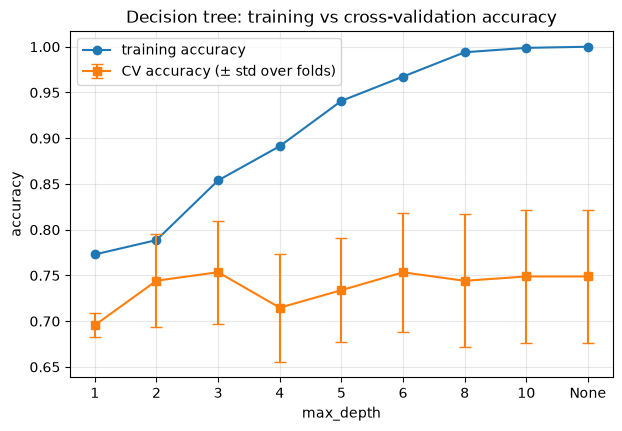

In [6]:
# 3b
import matplotlib.pyplot as plt
x = np.arange(len(depths))
plt.figure(figsize=(7, 4.5))
plt.plot(x, depth_table["train_acc"], "o-", label="training accuracy")
plt.errorbar(x, depth_table["cv_acc"], yerr=depth_table["cv_std"], fmt="s-", capsize=4, label="CV accuracy (± std over folds)")
plt.xticks(x, depth_table["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Decision tree: training vs cross-validation accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
# 3c
best_row = depth_table.loc[depth_table["cv_acc"].idxmax()]
se_best = best_row["cv_std"] / np.sqrt(cv.get_n_splits())
cutoff = best_row["cv_acc"] - se_best
eligible = depth_table[depth_table["cv_acc"] >= cutoff]
chosen_row = eligible.iloc[0]                       
best_depth = None if chosen_row["max_depth"] == "None" else int(chosen_row["max_depth"])

print(f"best mean CV acc = {best_row['cv_acc']:.4f} at max_depth={best_row['max_depth']}, SE = {se_best:.4f}, cutoff = {cutoff:.4f}")
print("eligible depths:", eligible["max_depth"].tolist())
print("chosen max_depth:", best_depth)

i = int(chosen_row.name)
for k in (i - 1, i + 1):
    if 0 <= k < len(depth_table):
        diff = chosen_row["cv_acc"] - depth_table.loc[k, "cv_acc"]
        print(f"vs max_depth={depth_table.loc[k, 'max_depth']}: diff = {diff:+.4f}  ({diff / chosen_row['cv_std']:+.2f} std of the chosen depth)")

best mean CV acc = 0.7535 at max_depth=3, SE = 0.0252, cutoff = 0.7283
eligible depths: [2, 3, 5, 6, 8, 10, 'None']
chosen max_depth: 2
vs max_depth=1: diff = +0.0487  (+0.96 std of the chosen depth)
vs max_depth=3: diff = -0.0093  (-0.18 std of the chosen depth)


In [8]:
# 3d
leaf_table = sweep("min_samples_leaf", [1, 2, 5, 10, 20, 40], max_depth=None)
leaf_table.round(4)

,min_samples_leaf,leaves,train_acc,cv_acc,cv_std
0,1,26.8,1.0000,0.7489,0.0728
1,2,24.4,0.9722,0.7439,0.0630
2,5,16.0,0.9046,0.7348,0.0696
3,10,9.6,0.8587,0.7487,0.0548
4,20,6.2,0.7923,0.7495,0.0628
5,40,3.0,0.7729,0.6956,0.0129


In [9]:
# 3e
final_tree = DecisionTreeClassifier(criterion="entropy", max_depth=best_depth, random_state=SEED).fit(X_train, y_train)
test_acc = final_tree.score(X_test, y_test)
se_test = np.sqrt(test_acc * (1 - test_acc) / len(y_test))
print(f"chosen max_depth={best_depth}, leaves={final_tree.get_n_leaves()}")
print(f"test accuracy = {test_acc:.4f} ± {se_test:.4f} (standard error, n = {len(y_test)})")

chosen max_depth=2, leaves=4
test accuracy = 0.7111 ± 0.0478 (standard error, n = 90)


In [10]:
# 4
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
scores = cross_validate(logreg, X_train, y_train, cv=cv, scoring=("accuracy", "f1"))
print(scores["test_accuracy"].mean(), scores["test_accuracy"].std(), scores["test_f1"].mean())

0.7879210220673635 0.0442848476899475 0.7613657756072616


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
tree_chosen = DecisionTreeClassifier(criterion="entropy", max_depth=best_depth, random_state=SEED)
tree_full = DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=SEED)
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)) 

In [12]:
# 4a
models = {f"tree (max_depth={best_depth})": tree_chosen, "tree (unlimited)": tree_full, "logistic regression": logreg}
cv_scores, rows = {}, []
for name, m in models.items():
    s = cross_validate(m, X_train, y_train, cv=cv, scoring=("accuracy", "f1"))
    cv_scores[name] = s
    rows.append({"model": name,
                 "CV accuracy mean": s["test_accuracy"].mean(),
                 "CV accuracy std": s["test_accuracy"].std(),
                 "CV F1 mean": s["test_f1"].mean()})
pd.DataFrame(rows).round(4)

,model,CV accuracy mean,CV accuracy std,CV F1 mean
0,tree (max_depth=2),0.7443,0.0508,0.7032
1,tree (unlimited),0.7489,0.0728,0.7234
2,logistic regression,0.7879,0.0443,0.7614


In [13]:
names = list(cv_scores)
acc = {n: cv_scores[n]["test_accuracy"] for n in names}
for a, b in [(names[0], names[2]), (names[0], names[1]), (names[1], names[2])]:
    d = acc[a] - acc[b]
    print(f"{a}  minus  {b}: mean diff = {d.mean():+.4f}, std of diffs = {d.std():.4f}, per-fold = {np.round(d, 3)}")

tree (max_depth=2)  minus  logistic regression: mean diff = -0.0437, std of diffs = 0.0543, per-fold = [ 0.    -0.048 -0.146 -0.024  0.   ]
tree (max_depth=2)  minus  tree (unlimited): mean diff = -0.0046, std of diffs = 0.0388, per-fold = [-0.048  0.     0.049  0.024 -0.049]
tree (unlimited)  minus  logistic regression: mean diff = -0.0390, std of diffs = 0.0892, per-fold = [ 0.048 -0.048 -0.195 -0.049  0.049]


In [14]:
# 4b
scaler = StandardScaler().fit(X_train)
tree_raw = DecisionTreeClassifier(criterion="entropy", max_depth=best_depth, random_state=SEED).fit(X_train, y_train)
tree_scaled = DecisionTreeClassifier(criterion="entropy", max_depth=best_depth, random_state=SEED).fit(scaler.transform(X_train), y_train)
pred_raw = tree_raw.predict(X_test)
pred_scaled = tree_scaled.predict(scaler.transform(X_test))
print("fraction of test rows with the same prediction:", np.mean(pred_raw == pred_scaled))

fraction of test rows with the same prediction: 1.0


In [15]:
# 4c
tree_hold = DecisionTreeClassifier(criterion="entropy", max_depth=best_depth, random_state=SEED).fit(X_train, y_train)
logreg_hold = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_train, y_train)

for name, m in [("tree", tree_hold), ("logistic regression", logreg_hold)]:
    p = m.predict(X_test)
    acc_t = accuracy_score(y_test, p)
    se = np.sqrt(acc_t * (1 - acc_t) / len(y_test))
    print(f"{name}: accuracy = {acc_t:.4f} (SE {se:.4f}), F1 = {f1_score(y_test, p):.4f}")
    print(pd.DataFrame(confusion_matrix(y_test, p),
                       index=["true 0", "true 1"], columns=["pred 0", "pred 1"]))
    print()

tree: accuracy = 0.7111 (SE 0.0478), F1 = 0.6061
        pred 0  pred 1
true 0      44       4
true 1      22      20

logistic regression: accuracy = 0.8778 (SE 0.0345), F1 = 0.8642
        pred 0  pred 1
true 0      44       4
true 1       7      35



In [16]:
# 5
from sklearn.tree import export_text

shallow = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED).fit(X_train, y_train)
print(export_text(shallow, feature_names=feature_names))
ranked = sorted(zip(shallow.feature_importances_, feature_names), reverse=True)
print([(name, round(float(imp), 3)) for imp, name in ranked[:5]])

|--- cp <= 3.50
|   |--- ca <= 0.50
|   |   |--- sex <= 0.50
|   |   |   |--- class: 0
|   |   |--- sex >  0.50
|   |   |   |--- class: 0
|   |--- ca >  0.50
|   |   |--- oldpeak <= 1.90
|   |   |   |--- class: 0
|   |   |--- oldpeak >  1.90
|   |   |   |--- class: 1
|--- cp >  3.50
|   |--- thal <= 6.50
|   |   |--- ca <= 0.50
|   |   |   |--- class: 0
|   |   |--- ca >  0.50
|   |   |   |--- class: 1
|   |--- thal >  6.50
|   |   |--- oldpeak <= 0.65
|   |   |   |--- class: 1
|   |   |--- oldpeak >  0.65
|   |   |   |--- class: 1

[('cp', 0.388), ('ca', 0.231), ('thal', 0.189), ('oldpeak', 0.136), ('sex', 0.055)]


In [18]:
# 5a
def leaf_rules(est, names):
    """List every leaf: path conditions, number of training patients, class counts [no disease, disease], predicted class."""
    t = est.tree_
    out = []

    def walk(node, conds):
        if t.children_left[node] == -1:
            v = t.value[node][0]
            counts = np.round(v / v.sum() * t.n_node_samples[node]).astype(int)
            out.append({"path": " AND ".join(conds), "n_patients": int(t.n_node_samples[node]),
                        "counts [0, 1]": counts.tolist(), "predicts": int(np.argmax(counts))})
        else:
            f, thr = names[t.feature[node]], t.threshold[node]
            walk(t.children_left[node], conds + [f"{f} <= {thr:.2f}"])
            walk(t.children_right[node], conds + [f"{f} > {thr:.2f}"])

    walk(0, [])
    return pd.DataFrame(out)


pd.set_option("display.max_colwidth", None)
leaf_rules(shallow, feature_names)

,path,n_patients,"counts [0, 1]",predicts
0,cp <= 3.50 AND ca <= 0.50 AND sex <= 0.50,27,"[27, 0]",0
1,cp <= 3.50 AND ca <= 0.50 AND sex > 0.50,52,"[43, 9]",0
2,cp <= 3.50 AND ca > 0.50 AND oldpeak <= 1.90,28,"[18, 10]",0
3,cp <= 3.50 AND ca > 0.50 AND oldpeak > 1.90,7,"[0, 7]",1
4,cp > 3.50 AND thal <= 6.50 AND ca <= 0.50,25,"[19, 6]",0
5,cp > 3.50 AND thal <= 6.50 AND ca > 0.50,15,"[2, 13]",1
6,cp > 3.50 AND thal > 6.50 AND oldpeak <= 0.65,15,"[3, 12]",1
7,cp > 3.50 AND thal > 6.50 AND oldpeak > 0.65,38,"[0, 38]",1


In [19]:
# 5b
def same_class_splits(est, names):
    """Internal nodes whose two children predict the same class, with the entropy before and after the split."""
    t = est.tree_
    rows = []
    for node in range(t.node_count):
        l, r = t.children_left[node], t.children_right[node]
        if l == -1:
            continue
        cls_l, cls_r = np.argmax(t.value[l][0]), np.argmax(t.value[r][0])
        if cls_l == cls_r:
            n, nl, nr = t.n_node_samples[node], t.n_node_samples[l], t.n_node_samples[r]
            weighted_children = (nl * t.impurity[l] + nr * t.impurity[r]) / n
            rows.append({"node": node, "split": f"{names[t.feature[node]]} <= {t.threshold[node]:.2f}",
                         "n": int(n), "both children predict": int(cls_l),
                         "entropy parent": round(t.impurity[node], 3),
                         "entropy left": round(t.impurity[l], 3), "entropy right": round(t.impurity[r], 3),
                         "weighted children": round(weighted_children, 3),
                         "info gain": round(t.impurity[node] - weighted_children, 3)})
    return pd.DataFrame(rows)


for d in (3, 4, 5, 6, None):
    est = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED).fit(X_train, y_train)
    found = same_class_splits(est, feature_names)
    if len(found):
        print(f"max_depth={d}: {len(found)} such split(s)")
        break
found

max_depth=3: 3 such split(s)


,node,split,n,both children predict,entropy parent,entropy left,entropy right,weighted children,info gain
0,1,ca <= 0.50,114,0,0.775,0.512,0.999,0.661,0.113
1,2,sex <= 0.50,79,0,0.512,0.000,0.665,0.438,0.074
2,12,oldpeak <= 0.65,53,1,0.314,0.722,0.000,0.204,0.109
